# More Plotnine snippets

## Introduction 

Some more snippets on doing unusual things with Plotnine

-----------------------

## Implementation

### Imports

- warnings can be used to supress unwanted warning message from plotnine
- numpy does numerical calulations (here, mostly random number generation)
- pandas handles dataframes
- plotnine, the star of the show
- scipy, scientific Python

In [1]:
import datetime
import warnings

import numpy as np
import pandas as pd
import plotnine as p9
import scipy

__watermark__ provides reproducability information

In [2]:
%load_ext watermark

-------------------------

## Enhancing line plots

This first section is about enhancing a simple line plot

### Create data

First, create a dataframe with increasing x, normally distributed y values 

In [3]:
x = list(range(50))

y = 10 + np.random.normal(0, 2, 50)

df = pd.DataFrame({"x": x, "y": y})

### Plot data

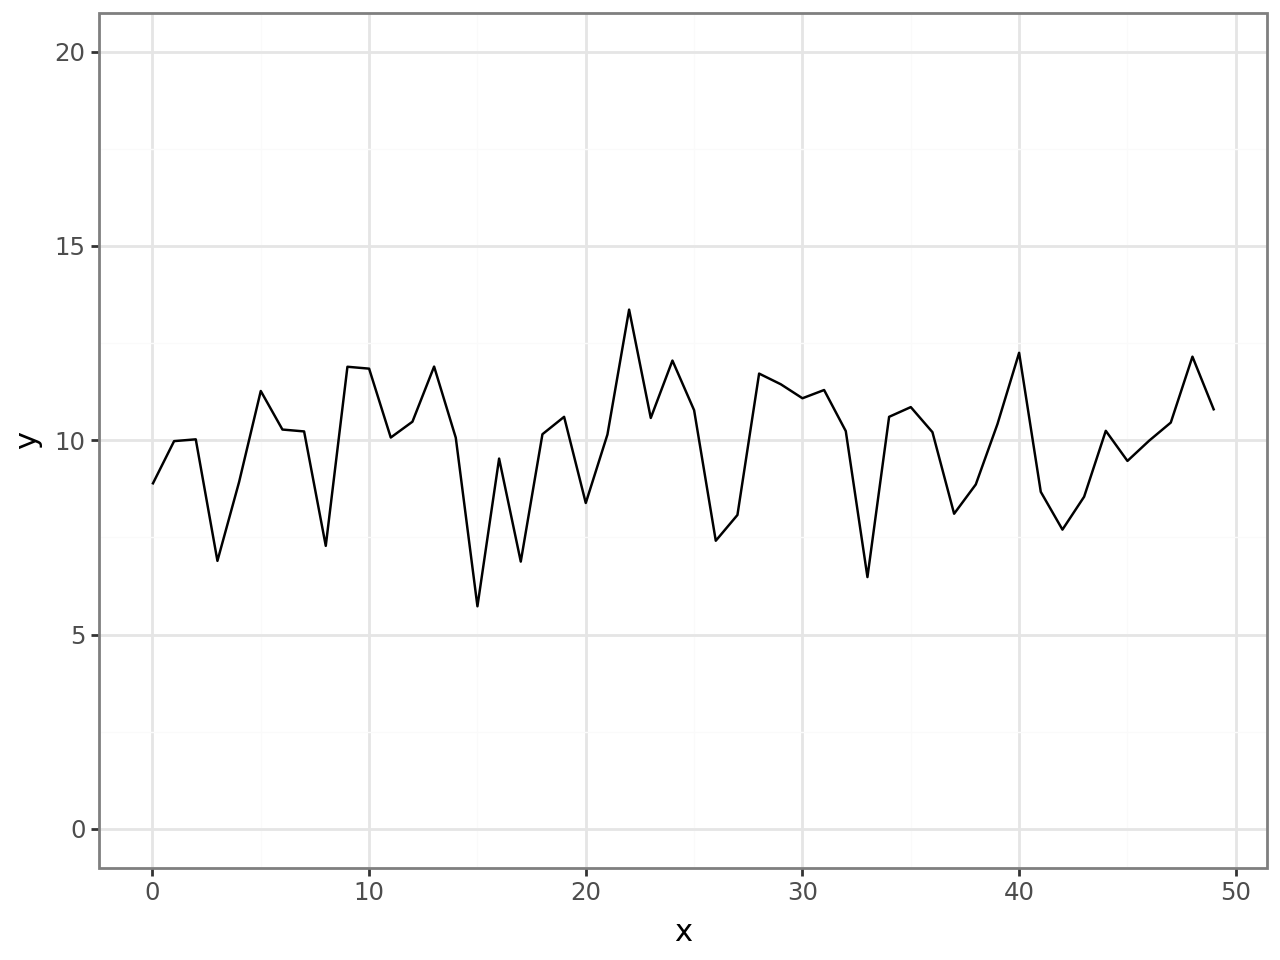

In [4]:
plot = (
    p9.ggplot(data=df)
    + p9.geom_line(mapping=p9.aes(x="x", y="y"))
    + p9.ylim((0, 20))
    + p9.theme_bw()
)
plot

So far, so good.  Add a Rug Plot to the Y axis to show distribution of y values

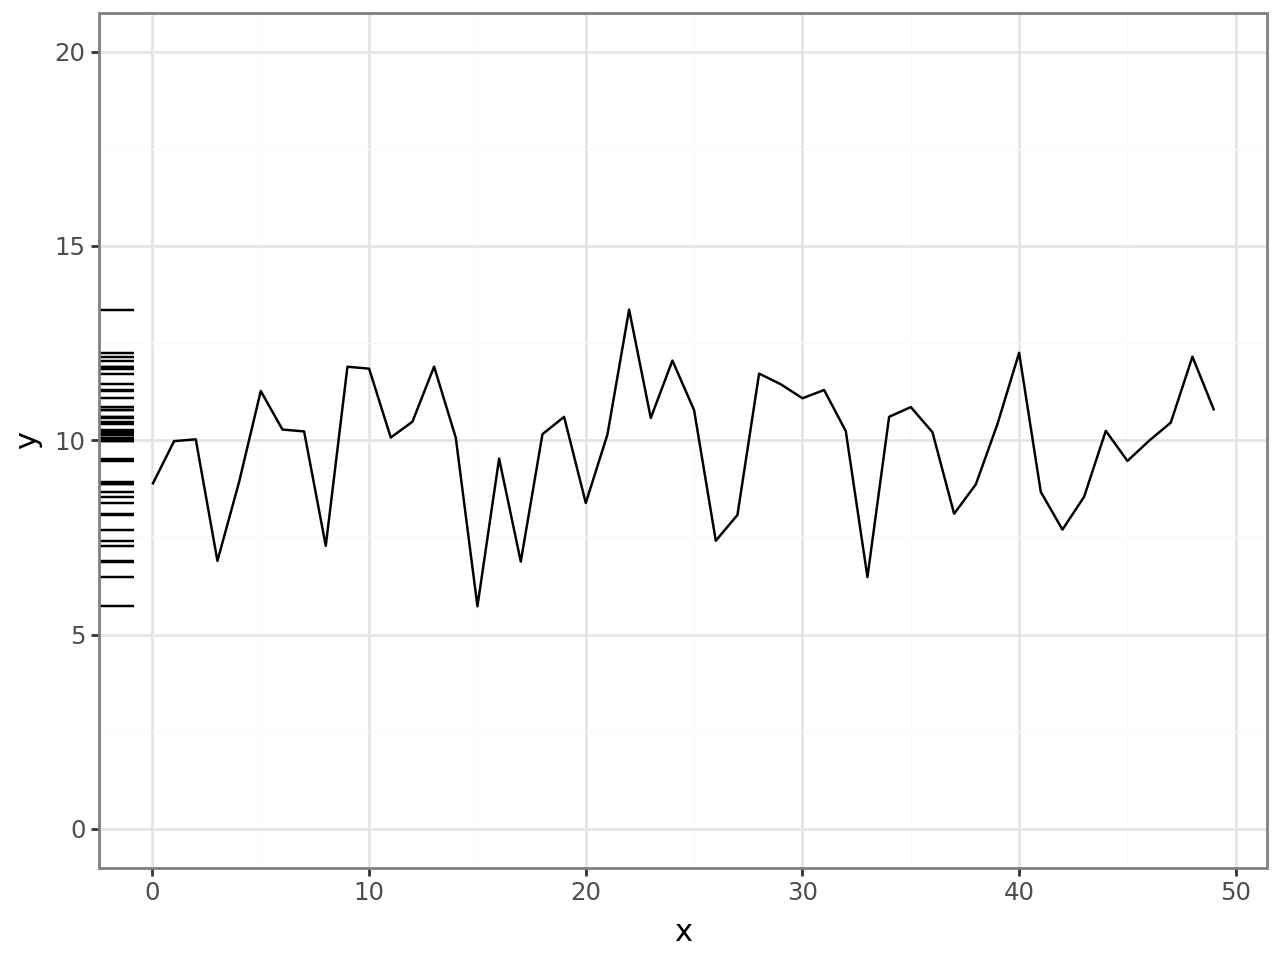

In [5]:
# add rug plot to y axis
plot + p9.geom_rug(mapping=p9.aes(y="y")) + p9.theme_bw()

In this iteration, we color code the rug plot by difference from the mean y value.  

We also:

- draw the individual data points, color coded for difference from the mean y value
- draw a rug plot on the y axis, where each whisker is color coded for difference from the mean y value
- draw an estimated y density plot to the left of the main curve, color coding the density curve for difference from the mean y value
- draw a baseline for our density curve

I chose the color map to get fainter, the more we get from the mean

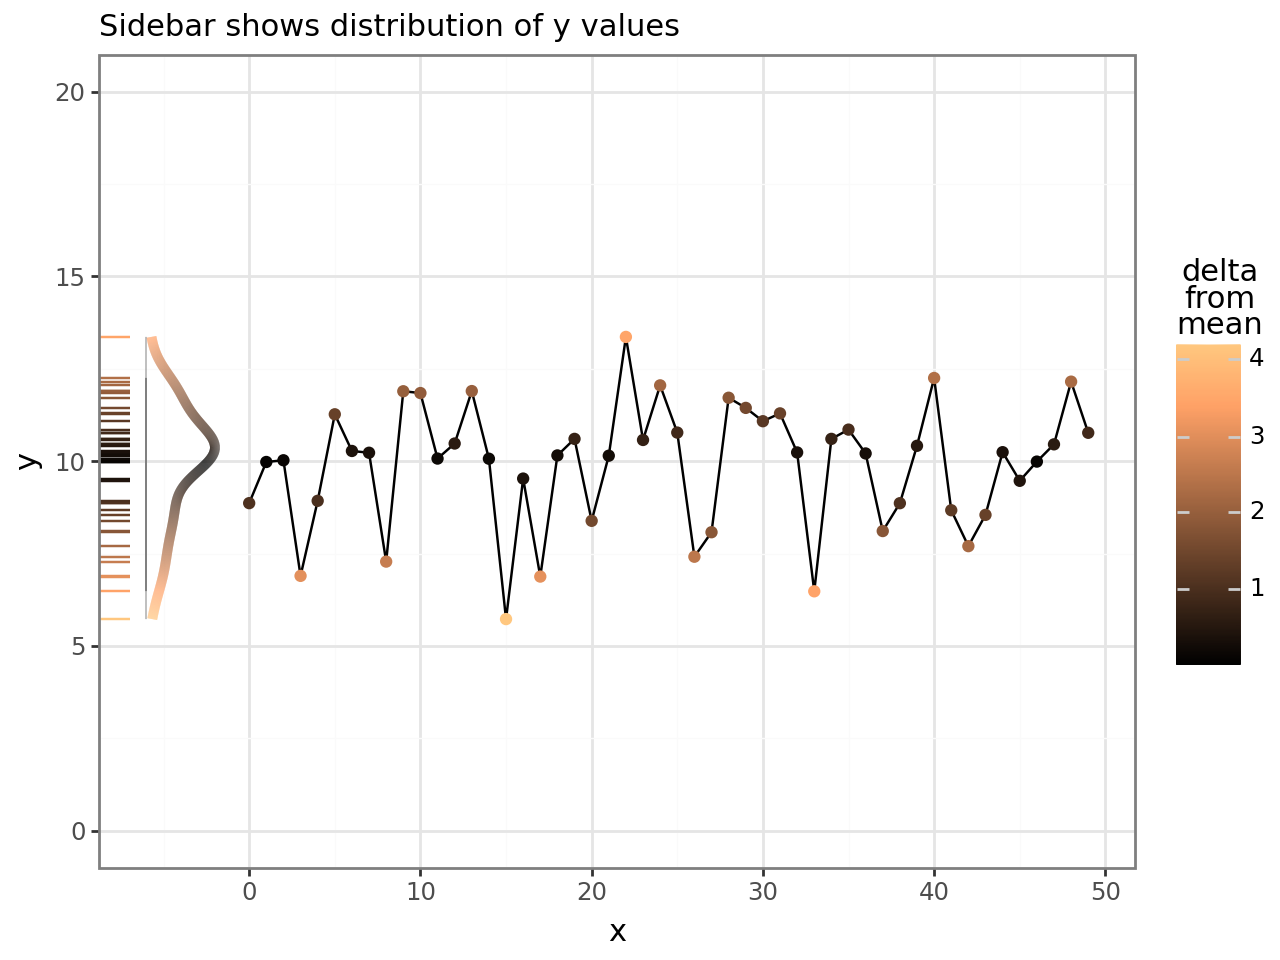

In [6]:
# get some curve statistics
xmin = df["x"].min()
xmax = df["x"].max()
y_mean = df["y"].mean()

# parameters for annotating y axis
scale = 4
shift = -6


(
    # take original line plot
    plot
    # add points, color coded for distance from y mean
    + p9.geom_point(mapping=p9.aes(x="x", y="y", color="abs(y-y_mean)"))
    # add y axis rug plot color coded for distance from  y mean
    + p9.geom_rug(mapping=p9.aes(y="y", color="abs(y-y_mean)"))
    # calculate y density curve, draw as path, color coded for distance from y mean
    # curve is shifted and scaled
    + p9.stat_ydensity(
        mapping=p9.aes(
            x=p9.after_stat("violinwidth*scale+shift"),
            y=p9.stage(start="y", after_stat="y"),
            color=p9.stage(start=0, after_stat="abs(y-y_mean)"),
        ),
        geom="path",
        kernel="gaussian",
        size=2,
    )
    # draw baseline of y density curve
    + p9.geom_path(mapping=p9.aes(x="shift", y="y"), color="gray", size=0.1)
    # label the plot
    + p9.labs(
        color="delta\nfrom\nmean", subtitle="Sidebar shows distribution of y values"
    )
    # chose color scheme
    + p9.scale_color_continuous(cmap_name="copper")
    # choose b&w style graphic
    + p9.theme_bw()
)

--------------------------

## Overlapping area plots

Suppose we have a number of subjects, and we measure the response to treatment x (in our example, response is a scaled Guassian, with a different mean for each subject, but the same variance).  We want to plot the responses in a single graphic.

### Create the data

In [7]:
x = []
y = []
subject = []

# number of treatment measurements (linearly spaced)
n_x = 20
# number of subjects
n_subject = 10

# create vector of x values as that give maximum response (random for each subject)
avs = np.random.randint(low=1, high=10, size=n_subject)

# treatment values
x_points = np.linspace(0, 10, n_x)

# create arrays holding treatment, response, subject id
for k in range(1, n_subject + 1):
    for x_i in x_points:
        x.append(x_i)
        subject.append(k)
        y.append(4 * scipy.stats.norm.pdf(x_i, loc=avs[k - 1], scale=1))
    # end for
# end for

Create a pandas dataframe (we want "subject" to be treated  as a discrete category, not a number)

In [8]:
df = pd.DataFrame({"x": x, "y": y, "subject": subject})

df["subject"] = (
    df["subject"]
    .astype("category")
    .cat.reorder_categories([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], ordered=True)
)

----------------------------------

### Plotting

We want a ridgeline style plot, with a series of solid response curves draw, one below the other.  Closer response curves will overlap and hide the curve over, to give the illusion of depth.

We can achieve this, because the plotnine process creates a pseudo-variable "group": in our mapping call, we ask plotnine to group data by Subject.  "group" is an integer value, and we can use this to shift each area plot up or down.  We chose down:  the curve that plotnine draws second (group=2) should overlap the first curve (group=1), so the second curve needs to be lower on the screen.  So we adjust each subjects __y__ values by __-group__

We draw the baselines for the area curves first, so that subsequent area plots will overlay (and obscure) them.  We outline each area curve with a gray line

Because we are plotting below the y=0 line (i.e. negative group values), the y axis tick mark labels will be misleading.  So we use __scale_y_continuous()__ to set tick marks at the -1, -2, 3, ... y axis locations, and label these 1, 2, 3 ... 

Finally we choose vibrant colors to distinguish the subjects

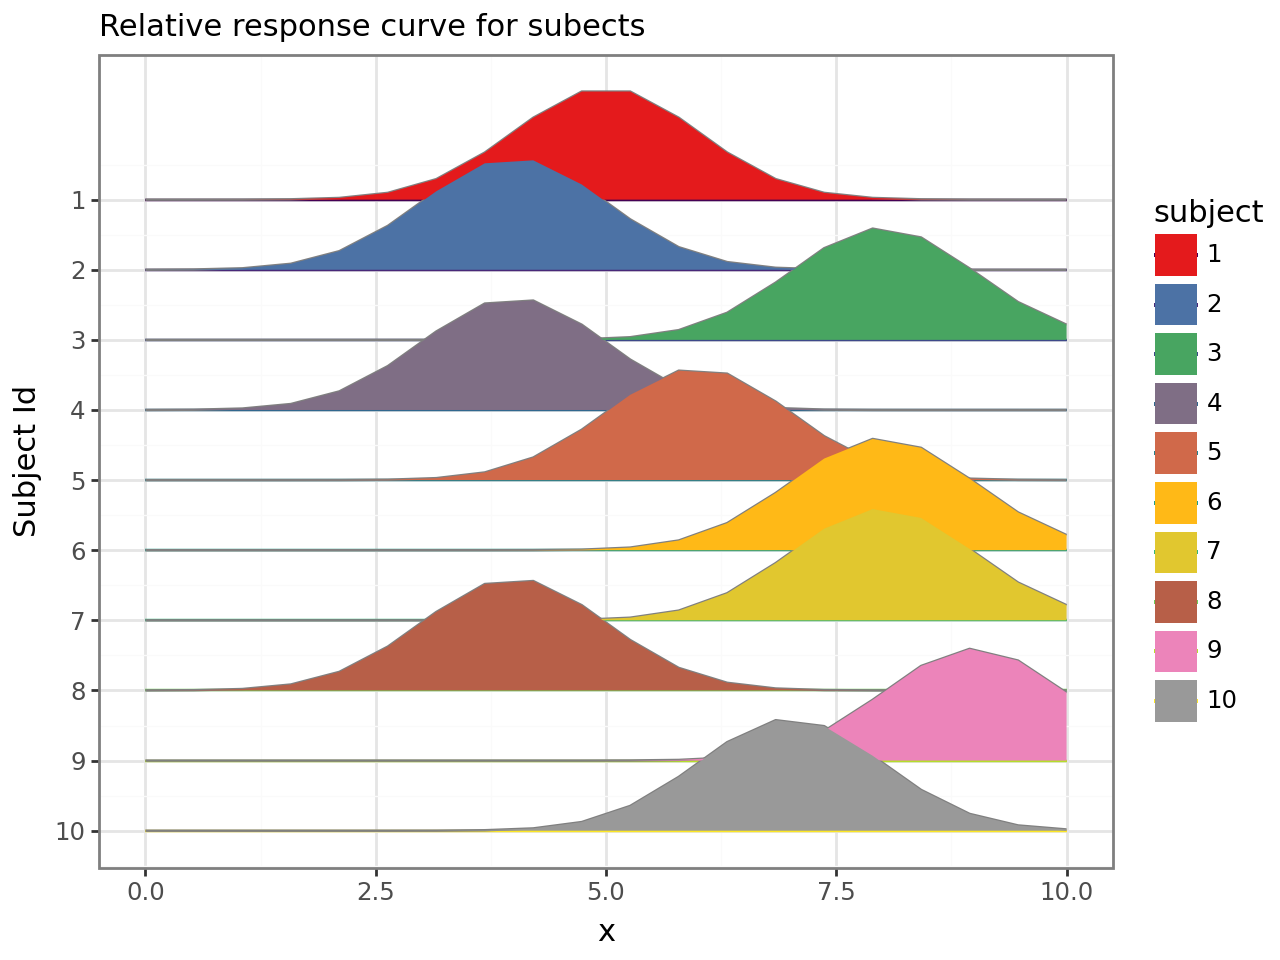

In [9]:
plot = (
    p9.ggplot(data=df)
    # draw baseline for each subject
    + p9.geom_line(
        mapping=p9.aes(
            x="x",
            y=p9.stage(start="0", after_stat="-group"),
            group="subject",
            color="subject",
        )
    )
    # draw response curve outline above baseline
    + p9.geom_line(
        mapping=p9.aes(
            x="x",
            y=p9.stage(start="y", after_stat="y-group"),
            group="subject",
        ),
        color="gray",
    )
    # fill in between subject baseline and subject line curve
    + p9.geom_ribbon(
        mapping=p9.aes(
            x="x",
            ymax=p9.stage(start=0, after_stat="y-group"),
            ymin=p9.stage(start=0, after_stat="-group"),
            group="subject",
            fill="subject",
        ),
        alpha=1,  # must have area plot opaque to get ridgeline effect
    )
    + p9.theme_bw()
    + p9.scale_y_continuous(
        breaks=[-i for i in range(1, n_subject + 1)],
        labels=[str(i) for i in range(1, n_subject + 1)],
    )
    + p9.labs(y="Subject Id", subtitle="Relative response curve for subects")
    + p9.scale_fill_cmap_d(cmap_name="Set1")
)
plot

----------------------

## Conclusions 

I consider the plot above to be a vast improvement over the graphic where we just plot area curves (unshifted) over each other (common baseline)

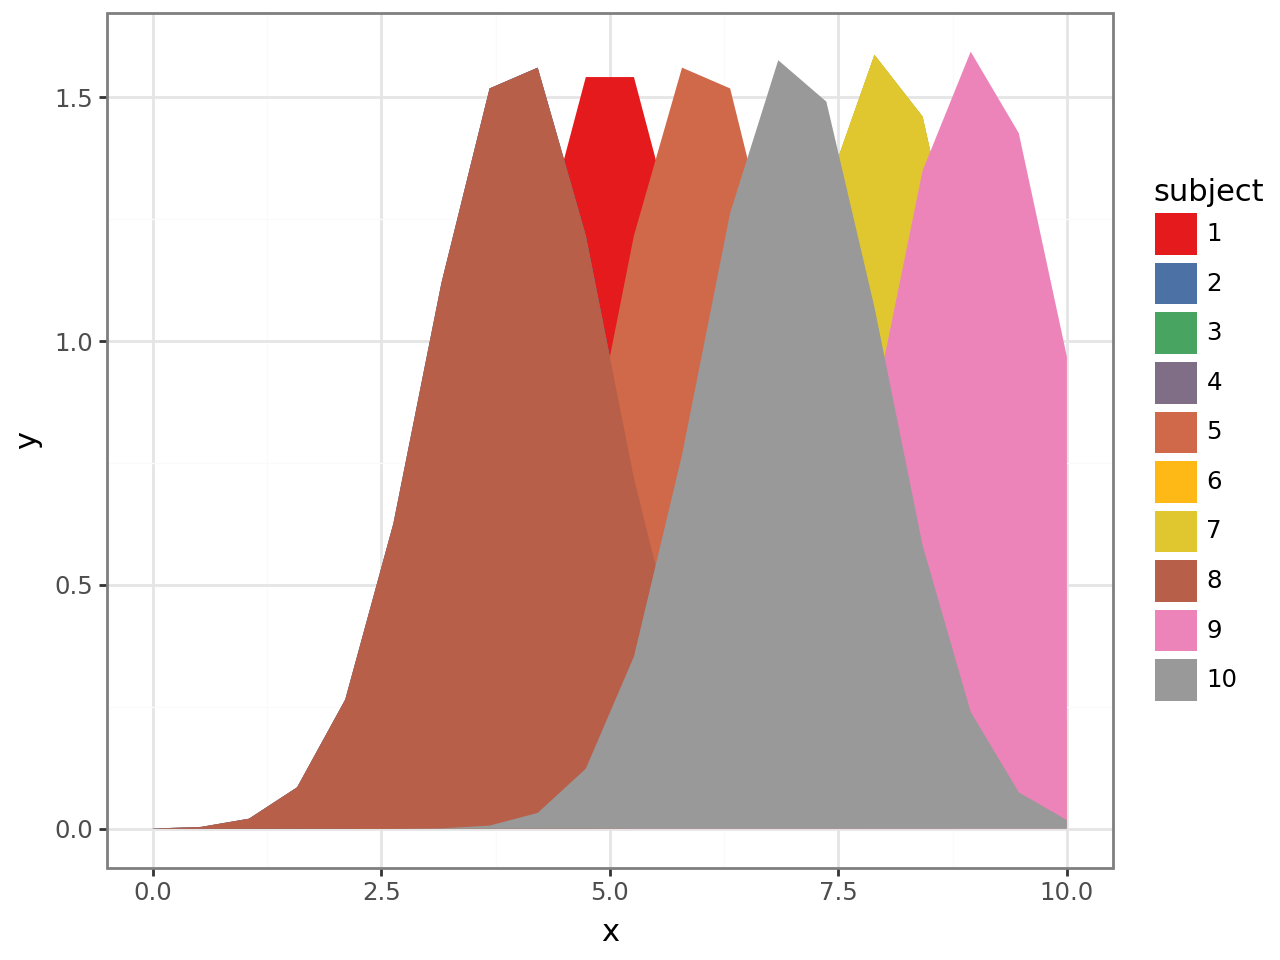

In [14]:
plot = (
    p9.ggplot(data=df)
    + p9.geom_area(
        mapping=p9.aes(x="x", y="y", group="subject", fill="subject"),
        position=p9.position_dodge(width=0),  # stop stacking of area curves
    )
    + p9.scale_fill_cmap_d(cmap_name="Set1")
    + p9.theme_bw()
)
plot

And also an improvement over common baseline line plots

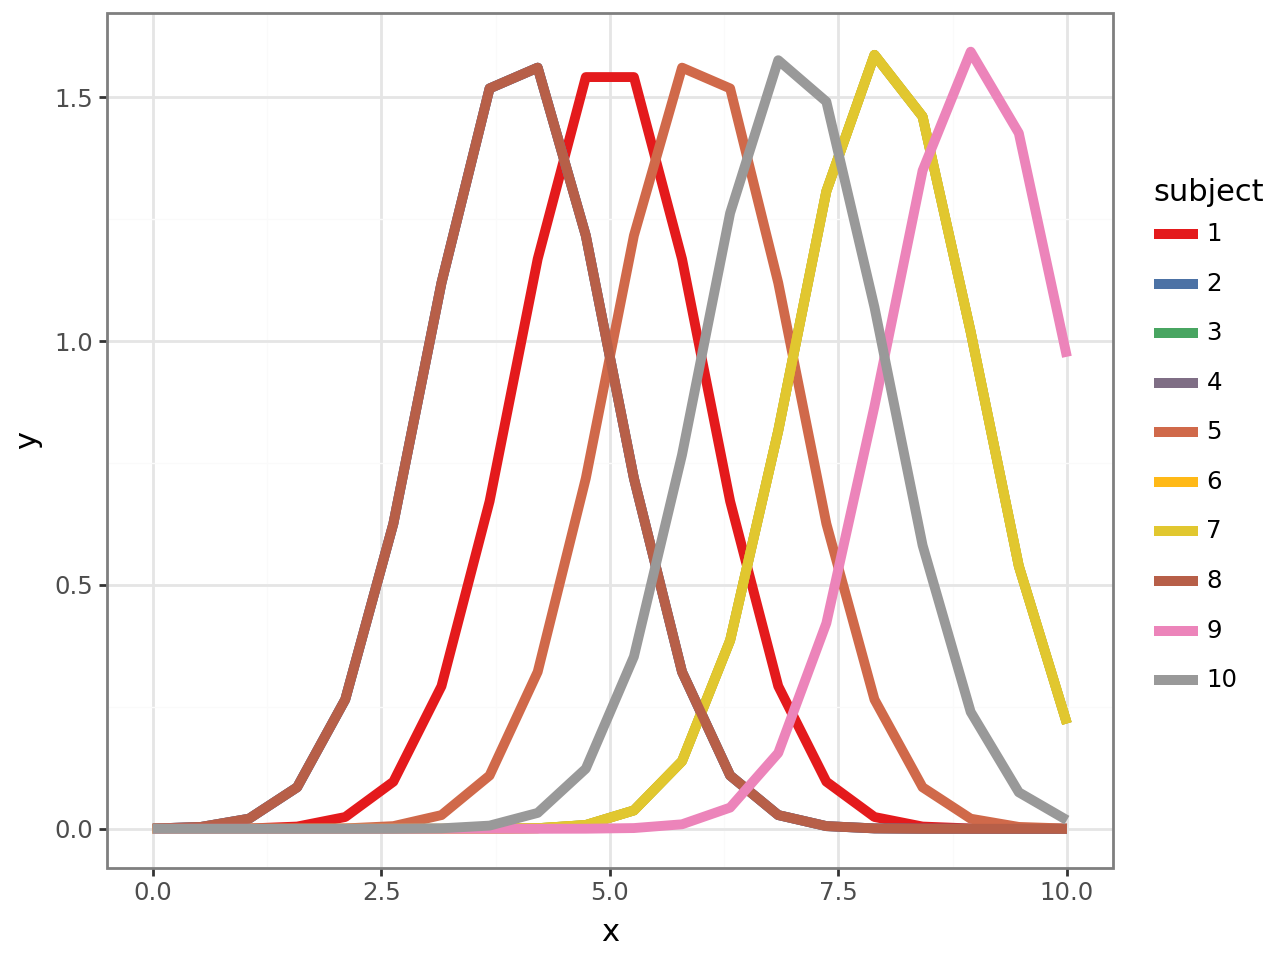

In [16]:
plot = (
    p9.ggplot(data=df)
    + p9.geom_line(
        mapping=p9.aes(x="x", y="y", group="subject", color="subject"),
        size=2, 
    )
    + p9.scale_color_cmap_d(cmap_name="Set1")
    + p9.theme_bw()
)
plot

------------------------

## Reproducability


In [110]:
%watermark

Last updated: 2026-03-09T19:32:06.644442+10:00

Python implementation: CPython
Python version       : 3.11.14
IPython version      : 9.10.0

Compiler    : MSC v.1929 64 bit (AMD64)
OS          : Windows
Release     : 10
Machine     : AMD64
Processor   : Intel64 Family 6 Model 170 Stepping 4, GenuineIntel
CPU cores   : 22
Architecture: 64bit



In [111]:
%watermark -h -iv -co

conda environment: fun_minim

Hostname: INSPIRON16

ipynbname: 2023.2.0.0
numpy    : 2.4.1
pandas   : 2.3.3
plotnine : 0.15.0
scipy    : 1.16.3



In [112]:
import contextlib

import ipynbname

with contextlib.suppress(FileNotFoundError):
    print(f"Notebook file name: {ipynbname.name()}")
# end with

Notebook file name: x_axis_density
